In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

# Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# Parameters
image_size = 32
batch_size = 64
latent_dim = 128
num_epochs = 20
learning_rate = 0.0002

Device: cpu


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

# CIFAR-10 is already present in the data folder
full_dataset = datasets.CIFAR10(
    root="data",
    train=True,
    download=False,
    transform=transform
)

# Use 10,000 images for training
dataset = Subset(
    full_dataset,
    range(10000)
)

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

print("Number of training images:", len(dataset))

Number of training images: 10000


In [3]:
class VAE(nn.Module):

    def __init__(self, latent_dim=128):
        super(VAE, self).__init__()

        # -------------------------
        # Encoder
        # -------------------------
        self.encoder = nn.Sequential(

            nn.Conv2d(
                3, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.Conv2d(
                64, 128,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(
                128, 256,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(
                256, 512,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2)
        )

        # Latent space
        self.fc_mu = nn.Linear(
            512 * 4 * 4,
            latent_dim
        )

        self.fc_logvar = nn.Linear(
            512 * 4 * 4,
            latent_dim
        )

        # -------------------------
        # Decoder
        # -------------------------

        self.fc_decode = nn.Linear(
            latent_dim,
            512 * 4 * 4
        )

        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(
                512, 256,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(
                256, 128,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(
                128, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(
                64, 3,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.Tanh()
        )

    # -------------------------
    # Encoder
    # -------------------------

    def encode(self, x):

        x = self.encoder(x)

        x = x.view(
            x.size(0),
            -1
        )

        mu = self.fc_mu(x)

        logvar = self.fc_logvar(x)

        return mu, logvar

    # -------------------------
    # Reparameterization Trick
    # -------------------------

    def reparameterize(
        self,
        mu,
        logvar
    ):

        std = torch.exp(
            0.5 * logvar
        )

        eps = torch.randn_like(std)

        return mu + eps * std

    # -------------------------
    # Decoder
    # -------------------------

    def decode(self, z):

        x = self.fc_decode(z)

        x = x.view(
            -1,
            512,
            4,
            4
        )

        return self.decoder(x)

    # -------------------------
    # Forward Pass
    # -------------------------

    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparameterize(
            mu,
            logvar
        )

        reconstruction = self.decode(z)

        return (
            reconstruction,
            mu,
            logvar
        )

In [4]:
model = VAE(
    latent_dim=latent_dim
).to(device)

print("VAE model created successfully.")
print(model)

VAE model created successfully.
VAE(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
    (9): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): LeakyReLU(negative_slope=0.2)
  )
  (fc_mu): Linear(in_features=8192, out_features=128, bias=True)
  (f

In [5]:
def vae_loss(
    reconstruction,
    original,
    mu,
    logvar
):

    # Reconstruction loss
    reconstruction_loss = F.mse_loss(
        reconstruction,
        original,
        reduction="sum"
    )

    # Prevent numerical instability
    logvar = torch.clamp(
        logvar,
        min=-10,
        max=10
    )

    # KL divergence
    kl_loss = -0.5 * torch.sum(
        1
        + logvar
        - mu.pow(2)
        - torch.exp(logvar)
    )

    # Weighted total loss
    total_loss = (
        reconstruction_loss
        + 0.05 * kl_loss
    )

    return total_loss

In [6]:
optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate
)

print("Optimizer:", optimizer)
print("Learning rate:", learning_rate)
print("Number of epochs:", num_epochs)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0002
    maximize: False
    weight_decay: 0
)
Learning rate: 0.0002
Number of epochs: 20


In [7]:
loss_history = []

for epoch in range(num_epochs):

    model.train()

    total_loss = 0

    for images, _ in dataloader:

        images = images.to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        reconstruction, mu, logvar = model(images)

        # Calculate loss
        loss = vae_loss(
            reconstruction,
            images,
            mu,
            logvar
        )

        # Backpropagation
        loss.backward()

        # Prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        # Update weights
        optimizer.step()

        total_loss += loss.item()

    average_loss = (
        total_loss / len(dataset)
    )

    loss_history.append(
        average_loss
    )

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Loss: {average_loss:.2f}"
    )

Epoch [1/20] Loss: 447.97
Epoch [2/20] Loss: 191.98
Epoch [4/20] Loss: 142.90
Epoch [5/20] Loss: 130.54
Epoch [6/20] Loss: 123.33
Epoch [7/20] Loss: 116.73
Epoch [8/20] Loss: 111.41
Epoch [9/20] Loss: 107.40
Epoch [12/20] Loss: 98.51
Epoch [13/20] Loss: 96.50
Epoch [14/20] Loss: 94.25
Epoch [15/20] Loss: 92.30
Epoch [16/20] Loss: 91.06
Epoch [17/20] Loss: 89.55
Epoch [19/20] Loss: 86.87
Epoch [20/20] Loss: 86.42


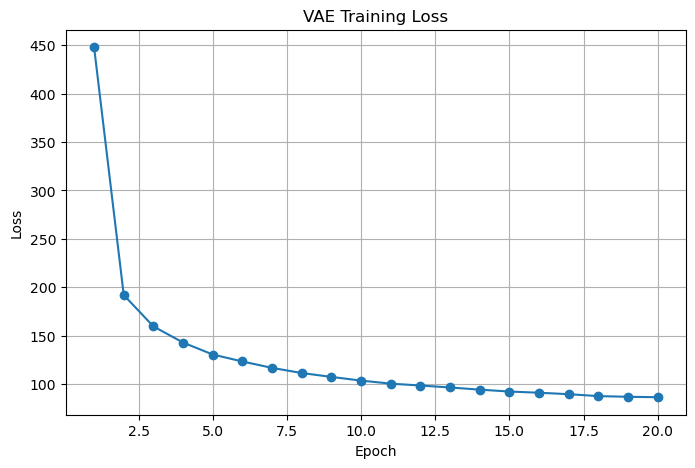

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    loss_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss")

plt.grid(True)

plt.show()

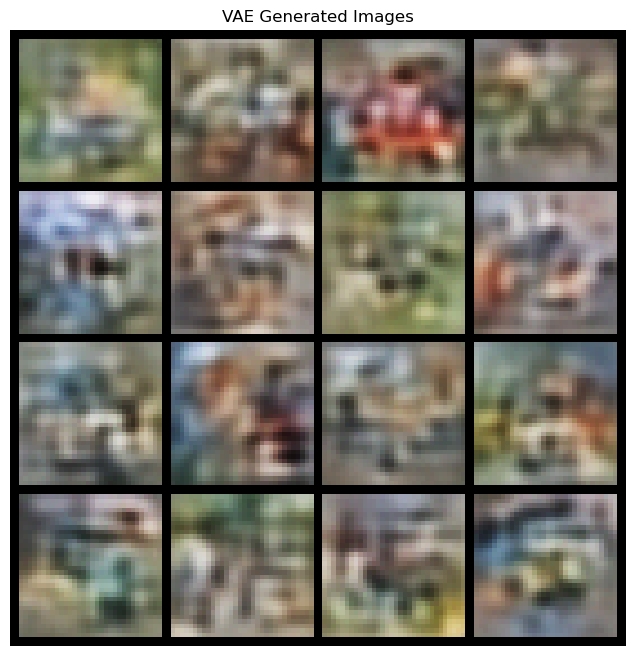

In [ ]:
model.eval()

with torch.no_grad():

    # Random points from latent space
    z = torch.randn(
        16,
        latent_dim
    ).to(device)

    # Generate new images
    generated_images = model.decode(z).cpu()

# Convert [-1, 1] to [0, 1]
generated_images = (
    generated_images * 0.5
) + 0.5

generated_images = generated_images.clamp(
    0,
    1
)

# Create image grid
grid = torchvision.utils.make_grid(
    generated_images,
    nrow=4
)

plt.figure(
    figsize=(8, 8)
)

plt.imshow(
    grid.permute(1, 2, 0)
)

plt.axis("off")

plt.title(
    "VAE Generated Images"
)

plt.show()